# Complete 3D Reconstruction Pipeline with Simple PyTorch NeRF

This notebook implements a complete 3D reconstruction pipeline using **only standard Python packages** - no COLMAP or nerfstudio required!

## Pipeline Overview

1. **Step 1: Data Preprocessing**
   - OpenCV-based Structure from Motion to compute camera poses
   - Pose-Derived Viewing Direction (PDVD) for scene center
   - Image Alignment Filtering (IAF) - OPTIONAL, disabled by default for 360° captures

2. **Step 2: Image Segmentation**
   - Apply trained segmentation model to filtered images
   - Generate PNG images with black backgrounds
   - Prepare data for NeRF training

3. **Step 3: 3D Reconstruction**
   - Train NeRF model using simple PyTorch implementation
   - Extract mesh using Marching Cubes algorithm
   - Export point cloud from trained model

## Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Add parent directory to path
sys.path.append('..')

from utils.preprocessing import ImagePreprocessor
from utils.segmentation import ImageSegmenter
from utils.nerf_reconstruction import NeRFReconstructor

print("✓ Imports successful")

✓ Imports successful


## Configuration

Set up paths and parameters for the reconstruction pipeline.

In [2]:
# Input/Output paths
FRAMES_DIR = "../frames"
OUTPUT_BASE_DIR = "../reconstructions/NeRF"
SEGMENTATION_MODEL = "../models/U-NET_seg.pt"
MODEL_TYPE = "U-NET"  # Options: U-NET, DeepLabV3Plus, SegFormer, SegNet, MaskFormer

# Preprocessing parameters
ANGLE_THRESHOLD = 20.0  # degrees - IAF filtering threshold
ENABLE_FILTERING = False  # Set False for 360° captures, True for forward-facing

# Segmentation parameters
SEG_THRESHOLD = 0.5  # Segmentation threshold
REFINE_MASKS = True  # Apply morphological refinement
REFINE_KERNEL_SIZE = 5  # Size of morphological kernel for refinement

# Reconstruction parameters (adjusted for simple NeRF)
MAX_ITERATIONS = 10000
MESH_RESOLUTION = 128  # Lower resolution for simple implementation
NUM_POINTS = 50000  # Fewer points for simple implementation
PREVIEW_EVERY = 1000  # Frequency of preview generation
PREVIEW_INDEX = 0  # Index of the preview image to generate

# Create output directories
preprocessing_dir = Path(OUTPUT_BASE_DIR) / "1_preprocessing"
segmentation_dir = Path(OUTPUT_BASE_DIR) / "2_segmentation"
reconstruction_dir = Path(OUTPUT_BASE_DIR) / "3_reconstruction"

print("Configuration:")
print(f"  Frames directory: {FRAMES_DIR}")
print(f"  Output directory: {OUTPUT_BASE_DIR}")
print(f"  Segmentation model: {SEGMENTATION_MODEL}")
print(f"  Segmentation threshold: {SEG_THRESHOLD}")
print(f"  Morphological refinement: {'ENABLED' if REFINE_MASKS else 'DISABLED'}")
print(f"  Angle threshold: {ANGLE_THRESHOLD}°")
print(f"  IAF Filtering: {'ENABLED' if ENABLE_FILTERING else 'DISABLED (recommended for 360° captures)'}")
print(f"  Max iterations: {MAX_ITERATIONS}")
print(f"  Method: Simple PyTorch NeRF (no external dependencies)")

Configuration:
  Frames directory: ../frames
  Output directory: ../reconstructions/NeRF
  Segmentation model: ../models/U-NET_seg.pt
  Segmentation threshold: 0.5
  Morphological refinement: ENABLED
  Angle threshold: 20.0°
  IAF Filtering: DISABLED (recommended for 360° captures)
  Max iterations: 10000
  Method: Simple PyTorch NeRF (no external dependencies)


---
# Step 1: Data Preprocessing

This step performs:
1. **Structure from Motion (SfM)** using **OpenCV** to compute camera poses (no COLMAP required)
2. **Pose-Derived Viewing Direction (PDVD)**: Construct scene center from camera positions
3. **Image Alignment Filtering (IAF)**: Filter images based on viewing angle (OPTIONAL - disabled by default for 360° captures)

**Note:** For 360° captures around an object, filtering is disabled by default since all views are valuable. Enable it only for forward-facing or focused captures.

In [3]:
print("="*70)
print("STEP 1: DATA PREPROCESSING")
print("="*70)

# Initialize preprocessor
preprocessor = ImagePreprocessor(
    images_dir=FRAMES_DIR,
    output_dir=str(preprocessing_dir),
    angle_threshold=ANGLE_THRESHOLD,
    enable_filtering=ENABLE_FILTERING  # Disabled by default for 360° captures
)

# Run full preprocessing pipeline
success = preprocessor.run_full_pipeline()

if success:
    print("\n✓ Step 1 completed successfully!")
    filtered_images_dir = preprocessing_dir / "filtered_images"
    transforms_json = preprocessing_dir / "transforms.json"
    print(f"  Filtered images: {filtered_images_dir}")
    print(f"  Camera poses: {transforms_json}")
else:
    print("\n✗ Step 1 failed!")
    raise RuntimeError("Preprocessing failed")

STEP 1: DATA PREPROCESSING
Starting Image Preprocessing Pipeline
Running OpenCV-based Structure from Motion...
  Found 219 images
  - Extracting features...
  - Features extracted from 219 images
  - Matching features and estimating poses...
✓ OpenCV SfM completed successfully
Extracting camera poses...
✓ Extracted poses for 219 images
✓ Scene center: [-3.080, -0.606, -0.462]
Filtering disabled - keeping all images
Saving filtered data...
  Resized frame_000000.png: scale=0.267, size=288x512
  Resized frame_000001.png: scale=0.267, size=288x512
  Resized frame_000002.png: scale=0.267, size=288x512
  Resized frame_000003.png: scale=0.267, size=288x512
  Resized frame_000004.png: scale=0.267, size=288x512
  Resized frame_000005.png: scale=0.267, size=288x512
  Resized frame_000006.png: scale=0.267, size=288x512
  Resized frame_000007.png: scale=0.267, size=288x512
  Resized frame_000008.png: scale=0.267, size=288x512
  Resized frame_000009.png: scale=0.267, size=288x512
  Resized frame_0

In [3]:
filtered_images_dir = preprocessing_dir / "filtered_images"
transforms_json = preprocessing_dir / "transforms.json"

### Visualize Preprocessing Results

Number of filtered images: 219
Camera intrinsics:
  Focal length: fx=133.33, fy=133.33
  Principal point: cx=68.27, cy=68.27
  Image size: 288x512


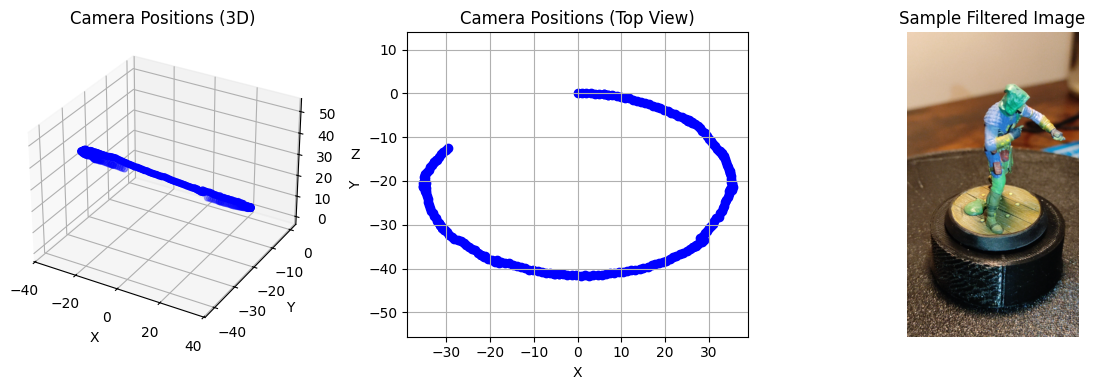

In [4]:
import json

# Load camera poses
with open(transforms_json, 'r') as f:
    transforms = json.load(f)

print(f"Number of filtered images: {len(transforms['frames'])}")
print(f"Camera intrinsics:")
print(f"  Focal length: fx={transforms['fl_x']:.2f}, fy={transforms['fl_y']:.2f}")
print(f"  Principal point: cx={transforms['cx']:.2f}, cy={transforms['cy']:.2f}")
print(f"  Image size: {transforms['w']}x{transforms['h']}")

# Visualize camera positions
fig = plt.figure(figsize=(12, 4))

# Extract camera positions
camera_positions = []
for frame in transforms['frames']:
    T = np.array(frame['transform_matrix'])
    camera_pos = T[:3, 3]
    camera_positions.append(camera_pos)

camera_positions = np.array(camera_positions)

# Plot camera positions
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], c='blue', marker='o')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Camera Positions (3D)')

ax2 = fig.add_subplot(132)
ax2.scatter(camera_positions[:, 0], camera_positions[:, 1], c='blue', marker='o')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Camera Positions (Top View)')
ax2.grid(True)
ax2.axis('equal')

# Display sample filtered images
ax3 = fig.add_subplot(133)
sample_images = list(filtered_images_dir.glob('*.png'))[:4]
if sample_images:
    img = Image.open(sample_images[0])
    ax3.imshow(img)
    ax3.set_title('Sample Filtered Image')
    ax3.axis('off')

plt.tight_layout()
plt.show()

---
# Step 2: Image Segmentation

This step applies a trained segmentation model to:
1. Segment the target object (rice panicle) from the background
2. Generate PNG images with transparent backgrounds
3. Prepare data for NeRF training

In [5]:
import torch

print("="*70)
print("STEP 2: IMAGE SEGMENTATION WITH CONTOUR-BASED APPROACH")
print("="*70)

# Initialize segmenter
segmenter = ImageSegmenter(
    model_path=SEGMENTATION_MODEL,
    model_type=MODEL_TYPE
)

# Create output directory
segmented_images_dir = segmentation_dir / "segmented_images"
segmented_images_dir.mkdir(parents=True, exist_ok=True)

# Segment all filtered images using contour-based approach
segmenter.segment_directory(
    input_dir=str(filtered_images_dir),
    output_dir=str(segmented_images_dir),
    threshold=SEG_THRESHOLD,
    refine=REFINE_MASKS,
    kernel_size=REFINE_KERNEL_SIZE,
    verbose=True
)
torch.cuda.empty_cache()
print("\n✓ Step 2 completed successfully!")
print(f"  Segmented images: {segmented_images_dir}")
print(f"  Used contour-based approach with threshold={SEG_THRESHOLD}")
print(f"  Morphological refinement: {'Applied' if REFINE_MASKS else 'Disabled'}")

STEP 2: IMAGE SEGMENTATION WITH CONTOUR-BASED APPROACH
Using device: cuda
✓ Loaded U-NET model from ../models/U-NET_seg.pt
Processing 219 images with contour-based segmentation...
  Processed 10/219 images
  Processed 20/219 images
  Processed 30/219 images
  Processed 40/219 images
  Processed 50/219 images
  Processed 60/219 images
  Processed 70/219 images
  Processed 80/219 images
  Processed 90/219 images
  Processed 100/219 images
  Processed 110/219 images
  Processed 120/219 images
  Processed 130/219 images
  Processed 140/219 images
  Processed 150/219 images
  Processed 160/219 images
  Processed 170/219 images
  Processed 180/219 images
  Processed 190/219 images
  Processed 200/219 images
  Processed 210/219 images
✓ Completed segmentation of 219 images
  Output directory: ..\reconstructions\NeRF\2_segmentation\segmented_images

✓ Step 2 completed successfully!
  Segmented images: ..\reconstructions\NeRF\2_segmentation\segmented_images
  Used contour-based approach with th

### Update transforms.json for Segmented Images

In [4]:
import shutil
import json

# Copy transforms.json to segmentation directory
shutil.copy2(transforms_json, segmentation_dir / "transforms.json")

# Update file paths to point to segmented images
with open(segmentation_dir / "transforms.json", 'r') as f:
    transforms = json.load(f)

for frame in transforms['frames']:
    old_path = frame['file_path']
    filename = Path(old_path).name
    # Change to .png extension
    filename = Path(filename).stem + ".png"
    frame['file_path'] = f"./segmented_images/{filename}"

with open(segmentation_dir / "transforms.json", 'w') as f:
    json.dump(transforms, f, indent=2)

print(f"✓ Updated transforms.json: {segmentation_dir / 'transforms.json'}")

✓ Updated transforms.json: ..\reconstructions\NeRF\2_segmentation\transforms.json


### Visualize Segmentation Results

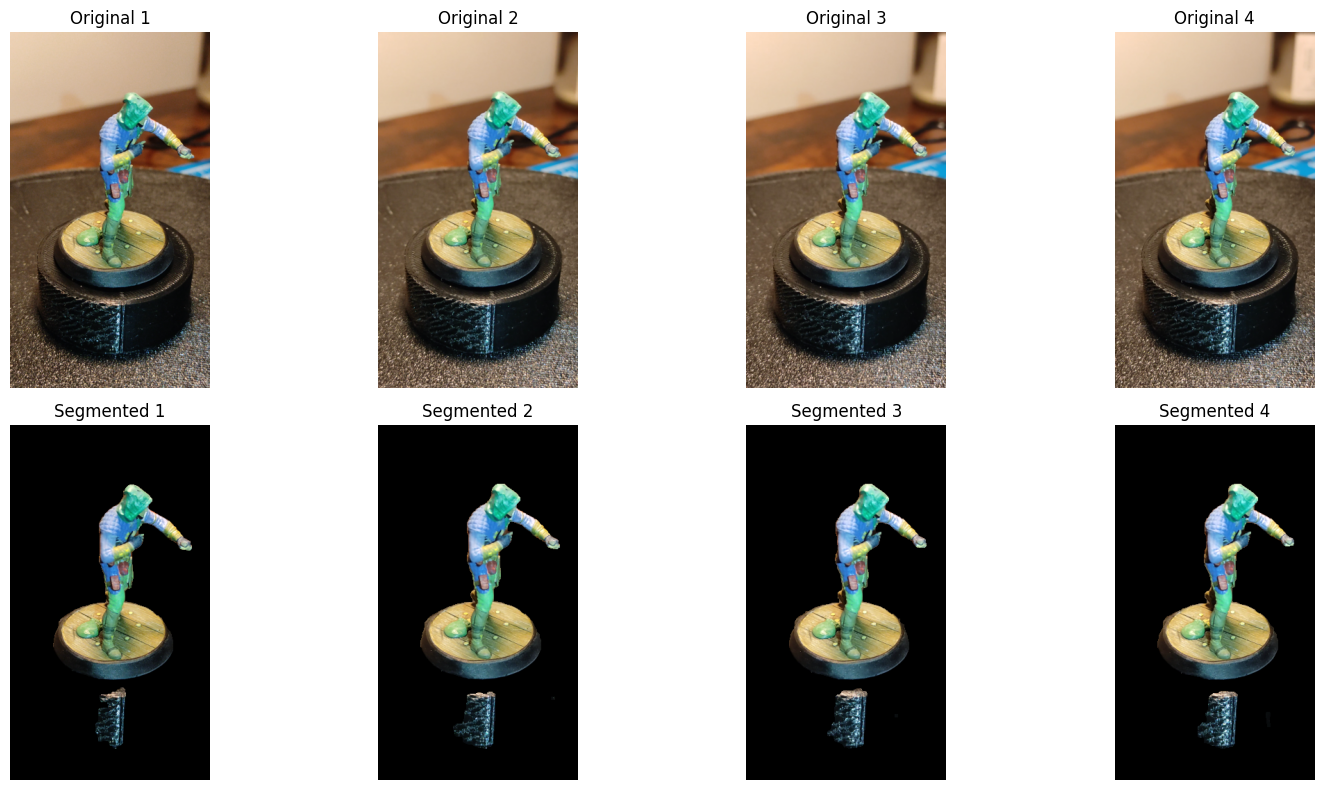

In [7]:
# Compare original and segmented images
sample_images = list(segmented_images_dir.glob('*.png'))[:4]

if sample_images:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, seg_img_path in enumerate(sample_images):
        if i >= 4:
            break
        
        # Find corresponding original image
        orig_img_path = filtered_images_dir / seg_img_path.name
        
        # Load images
        orig_img = Image.open(orig_img_path)
        seg_img = Image.open(seg_img_path)
        
        # Display original
        axes[0, i].imshow(orig_img)
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')
        
        # Display segmented (with transparency visualized on checkerboard)
        # Create checkerboard pattern
        checker_size = 20
        h, w = seg_img.size[1], seg_img.size[0]
        checker = np.zeros((h, w, 3), dtype=np.uint8)
        for y in range(0, h, checker_size):
            for x in range(0, w, checker_size):
                color = 200 if ((x // checker_size) + (y // checker_size)) % 2 == 0 else 150
                checker[y:y+checker_size, x:x+checker_size] = color
        
        # Composite segmented image over checkerboard
        seg_array = np.array(seg_img)
        if seg_array.shape[2] == 4:  # Has alpha channel
            alpha = seg_array[:, :, 3:4] / 255.0
            rgb = seg_array[:, :, :3]
            composite = (rgb * alpha + checker * (1 - alpha)).astype(np.uint8)
        else:
            composite = seg_array[:, :, :3]
        
        axes[1, i].imshow(composite)
        axes[1, i].set_title(f'Segmented {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No segmented images found")

---
# Step 3: 3D Reconstruction with Simple PyTorch NeRF

This step performs:
1. **NeRF Training**: Train a simplified PyTorch-based NeRF model on multi-view segmented images
2. **Mesh Extraction**: Use Marching Cubes to extract triangular mesh from density field
3. **Point Cloud Export**: Extract point cloud from trained NeRF model

**Note:** This uses a pure PyTorch implementation - no nerfstudio or instant-ngp required!

### Train Simple NeRF Model

This will take 10-30 minutes depending on your GPU.

In [4]:
print("="*70)
print("STEP 3: 3D RECONSTRUCTION WITH SIMPLE PYTORCH NERF")
print("="*70)

# Initialize reconstructor
reconstructor = NeRFReconstructor(
    data_dir=str(segmentation_dir),
    output_dir=str(reconstruction_dir)
)

# Run full reconstruction
print("\nThis may take 10-30 minutes...")
success = reconstructor.run_full_reconstruction(
    max_iterations=MAX_ITERATIONS,
    mesh_resolution=MESH_RESOLUTION,
    num_points=NUM_POINTS,
    preview_every=PREVIEW_EVERY,
    preview_index=PREVIEW_INDEX
)

if success:
    print("\n✓ Step 3 completed successfully!")
    print(f"  Reconstruction outputs: {reconstruction_dir}")
else:
    print("\n✗ Step 3 failed!")
    print("\nNote: Check error messages above for details.")

STEP 3: 3D RECONSTRUCTION WITH SIMPLE PYTORCH NERF
✓ Initialized reconstructor for ..\reconstructions\NeRF\2_segmentation
  Using: Simple PyTorch NeRF

This may take 10-30 minutes...
Starting 3D Reconstruction
Using Simple PyTorch NeRF implementation...
INSTANT NGP TRAINING (Hash Encoding)
Using device: cuda
Loading images and poses...
Loaded 219 images
Image size: 512x288
Intrinsics: fx=133.3, fy=133.3, cx=68.3, cy=68.3
Scene center: [  2.5441787 -23.996445   29.826136 ], radius: 76.731
Camera distance range: 27.110 to 38.365

Training for 10000 iterations...
Iteration 100/10000, Loss: 0.052766
Iteration 200/10000, Loss: 0.054311
Iteration 300/10000, Loss: 0.048343
Iteration 400/10000, Loss: 0.027138
Iteration 500/10000, Loss: 0.017279
Iteration 600/10000, Loss: 0.021341
Iteration 700/10000, Loss: 0.058254
Iteration 800/10000, Loss: 0.014752
Iteration 900/10000, Loss: 0.040052
Iteration 1000/10000, Loss: 0.007512
Rendering preview (RGB + depth)...
\nDebugging network output...
  Color

### Visualize Results

Output files:
  ✗ Mesh not found
  ✓ Point cloud: ..\reconstructions\NeRF\3_reconstruction\pointcloud.ply
    Size: 0.12 MB

Loading point cloud for visualization...


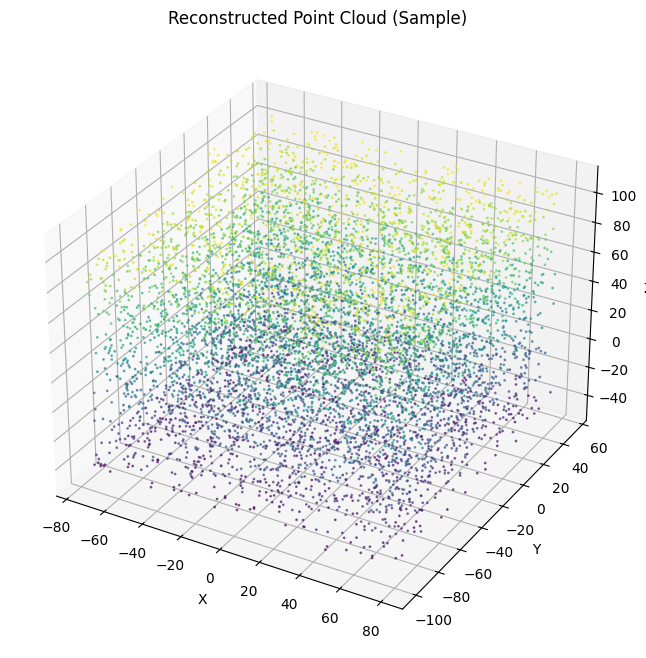

Total points in full point cloud: 7,363


In [8]:
# Check for output files
mesh_file = reconstruction_dir / "mesh.ply"
pointcloud_file = reconstruction_dir / "pointcloud.ply"

print("Output files:")
if mesh_file.exists():
    print(f"  ✓ Mesh: {mesh_file}")
    print(f"    Size: {mesh_file.stat().st_size / 1e6:.2f} MB")
else:
    print(f"  ✗ Mesh not found")

if pointcloud_file.exists():
    print(f"  ✓ Point cloud: {pointcloud_file}")
    print(f"    Size: {pointcloud_file.stat().st_size / 1e6:.2f} MB")
else:
    print(f"  ✗ Point cloud not found")

# Visualize if trimesh is available
try:
    import trimesh
    
    if pointcloud_file.exists():
        print("\nLoading point cloud for visualization...")
        pc = trimesh.load(str(pointcloud_file))
        
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Sample points for visualization (max 10000 for performance)
        points = pc.vertices
        if len(points) > 10000:
            indices = np.random.choice(len(points), 10000, replace=False)
            points = points[indices]
        
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                  c=points[:, 2], cmap='viridis', s=1, alpha=0.6)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title('Reconstructed Point Cloud (Sample)')
        plt.show()
        
        print(f"Total points in full point cloud: {len(pc.vertices):,}")
    
except ImportError:
    print("\nInstall trimesh for 3D visualization: pip install trimesh")

In [7]:
import sys
sys.path.append("../")
from utils.pointCloud import visualize_point_cloud
visualize_point_cloud("../reconstructions/NeRF/3_reconstruction/pointcloud.ply")